# Lazy Browse — DestinE Climate DT Monthly Portfolio

This notebook provides an **instant xarray view** of DestinE Climate DT Generation 2 data.
Variables and coordinates appear immediately, actual data is fetched from the data bridge **only when you access values** (e.g. plotting, `.values`, `.compute()`).

**Prerequisites:**
- `conda activate destine`
- `~/.polytopeapirc` configured (see `docs/polytope_setup.md`)

In [1]:
import logging, warnings
import earthkit.data

# Silence verbose output from polytope / earthkit internals
for _ln in ("polytope", "polytope.api", "earthkit.data", "urllib3"):
    logging.getLogger(_ln).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
import sys, os
# Make sure local modules are importable from the notebook directory
_here = os.getcwd()
if _here not in sys.path:
    sys.path.insert(0, _here)

import numpy as np
import pandas as pd
from polytope_zarr import PolytopeZarrStore
from destine_portfolio import PORTFOLIO_GEN2_CLMN

## 1. Define the store (metadata only — no download yet)

Pick a levtype and model.  Start with **one model** to keep requests fast;
add more models later once you've confirmed connectivity.

In [3]:
# ── Configuration ─────────────────────────────────────────────────

# ── Choose a levtype (uncomment one) ──────────────────────────────
LEVTYPE = "sfc"                    # 34 vars — surface atmosphere
# LEVTYPE = "pl"                   #  9 vars — pressure levels (19 levels, 1000–1 hPa)
# LEVTYPE = "hl"                   #  2 vars — height levels (100 m, IFS-only)
# LEVTYPE = "sol"                  #  2 vars — soil / snow (5 levels)
# LEVTYPE = "o2d"                  # 13 vars — 2-D ocean & sea ice
# LEVTYPE = "o3d"                  #  5 vars — 3-D ocean (up to 75 levels)

# Start with ONE model for quick testing; add more later.
store = PolytopeZarrStore.from_climate_dt(
    models=["IFS-FESOM"],  # or ["ICON"], ["IFS-NEMO"]
    experiment="hist", # 'cont', 'hist', 'SSP3-7.0'
    resolution="standard", # 'standard', 'high'
    levtype=LEVTYPE,
    years=range(2010, 2011), # 1 year for quick testing
)
print(store)

<PolytopeZarrStore 34 variables (time=12, cell=196608, model=1)>


## 2. Verify connectivity (recommended before fetching data)

`store.verify()` makes a single small Polytope request to confirm
your credentials, parameter names, and server are all working.
Only takes a few seconds.

In [4]:
result = store.verify()
print(result["message"])
if result["ok"]:
    print("\n✓ Ready to proceed. Open the store with store.open() and start fetching.")
else:
    print("\n✗ Verify failed — check:")
    print("  - ~/.polytopeapirc is valid (re-run desp-authentication.py)")
    print("  - The model + levtype + experiment combination exists")
    print("  - Network connectivity to Polytope servers")
    print("\nDetails:", result["details"])

2026-07-16 16:03:27 - INFO - Key read from /home/dorian.spat/.polytopeapirc
2026-07-16 16:03:27 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            "month: '1'\n"
            'param: avg_tclw\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clmn\n'
            'type: fc\n'
            "year: '2010'\n",
 'verb': 'retrieve'}
2026-07-16 16:03:27 - INFO - Polytope user key found in session cache for user dorian.spat
2026-07-16 16:03:28 - INFO - Request accepted. Please poll ./cad54877-3fe5-4c8e-b3e4-af6fd5fe3bfa for status
2026-07-16 16:03:28 - INFO - Polytope user key found in session cache for user dorian.spat
2026-07-16 16:03:28 - INFO - Checking request status (cad54877-3fe5-4c8e-b3e4-af6fd5fe3bfa)...
2

cad54877-3fe5-4c8e-b3e4-af6fd5fe3bfa.grib:   0%|          | 0.00/458k [00:00<?, ?B/s]

✓ Connected: avg_tclw for IFS-FESOM at 2010-01-01 00:00:00 — 196,608 of 196,608 pixels valid (range 0.0–0.3)

✓ Ready to proceed. Open the store with store.open() and start fetching.


## 3. Open as xarray Dataset

This is **instant** — no data downloaded yet. You see all variables,
dimensions, and coordinate values.

In [5]:
ds = store.open()
ds

<xarray.Dataset> Size: 322MB
Dimensions:       (model: 1, time: 12, cell: 196608)
Coordinates:
  * model         (model) object 8B 'IFS-FESOM'
  * time          (time) datetime64[ns] 96B 2010-01-01 2010-02-01 ... 2010-12-01
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    avg_10u       (model, time, cell) float32 9MB ...
    avg_10v       (model, time, cell) float32 9MB ...
    avg_10ws      (model, time, cell) float32 9MB ...
    avg_2d        (model, time, cell) float32 9MB ...
    avg_2t        (model, time, cell) float32 9MB ...
    avg_ie        (model, time, cell) float32 9MB ...
    ...            ...
    avg_tnlwrf    (model, time, cell) float32 9MB ...
    avg_tnlwrfcs  (model, time, cell) float32 9MB ...
    avg_tnswrf    (model, time, cell) float32 9MB ...
    avg_tnswrfcs  (model, time, cell) float32 9MB ...
    avg_tprate    (model, time, cell) float32 9MB ...
    avg_tsrwe     (model, time, cell) float32 9MB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=12, cell=196608, ...

## 4. Plot a single monthly field (triggers lazy fetch)

Only now does the store actually call Polytope — fetching data for the
selected model, time, and variable.

In [6]:
import healpy as hp
import matplotlib.pyplot as plt

field = ds["avg_2t"].sel(model="IFS-FESOM", time="2010-06-01")
print(f"Fetching {dict(field.sizes)} values...")  # triggers the Polytope request
field_values = field.values

# Sanity check: verify data arrived
n_valid = np.sum(~np.isnan(field_values))
n_nan = np.sum(np.isnan(field_values))
print(f"  Valid pixels: {n_valid:,}  |  NaN pixels: {n_nan:,}  "
      f"({100*n_valid/field_values.size:.1f}% valid)")
if n_valid == 0:
    print("  ⚠ ALL pixels are NaN — data fetch likely failed. Check store.verify().")
elif n_valid > 0 and n_nan > n_valid * 0.5:
    print("  ⚠ More NaN than valid — ocean pixels are NaN for atmosphere vars, this is normal.")
else:
    print(f"  ✓ min={np.nanmin(field_values):.1f}  max={np.nanmax(field_values):.1f}")

Fetching {'cell': 196608} values...
  ⚡ batching 12 time chunks for avg_2t


c21ca943-a389-42c9-83e2-fc2a12394046.grib:   0%|          | 0.00/5.05M [00:00<?, ?B/s]

  Valid pixels: 196,608  |  NaN pixels: 0  (100.0% valid)
  ✓ min=214.8  max=315.4


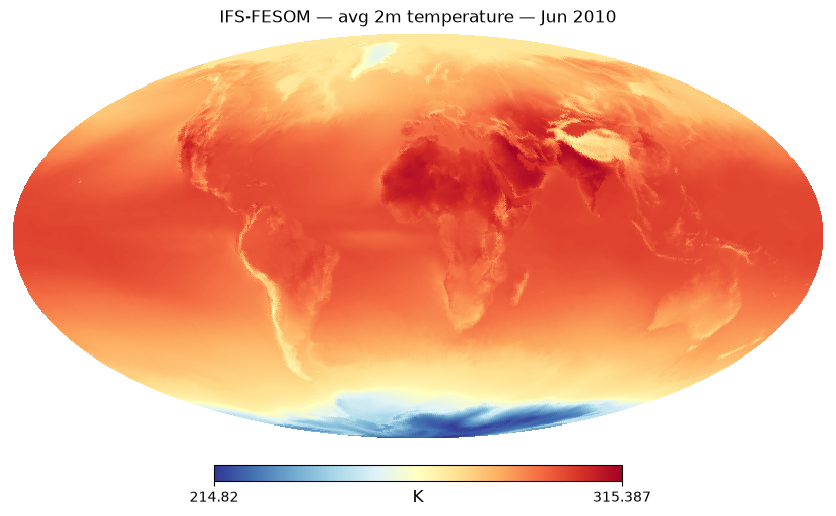

In [7]:
hp.mollview(field_values, title="IFS-FESOM — avg 2m temperature — Jun 2010",
            unit="K", cmap="RdYlBu_r", nest=True, flip='geo')
plt.show()

In [ ]:
# Annual mean precipitation rate
field2 = ds["avg_tprate"].sel(model="IFS-FESOM", time=slice("2010-01", "2010-12")).mean("time")
field2_values = field2.values  # triggers the Polytope request

In [ ]:
n_valid2 = np.sum(~np.isnan(field2_values))
print(f"Valid pixels: {n_valid2:,}  |  NaN: {field2_values.size - n_valid2:,}  "
      f"({100*n_valid2/field2_values.size:.1f}% valid)")
hp.mollview(field2_values,
            title="IFS-FESOM — avg total precipitation rate — year 2010",
            unit="kg m**-2 s**-1", cmap="Blues", min=0, nest=True, flip='geo')
plt.show()

## 5. Compare experiments: climate change signal (optional)

Create a second store for the scenario experiment, then take the difference to the historical.
`.polytope.sel()` automatically sets `batch_years` from the time slice so each call fetches all requested years in one Polytope request.

> **Note:** ICON scenario data is available to **2040**; IFS-NEMO/IFS-FESOM to **2049**.
> When slicing ICON scenario data, use `time=slice("2015-01", "2040-12")`.

In [ ]:
scen_store = PolytopeZarrStore.from_climate_dt(
    models=["IFS-FESOM"],
    experiment="SSP3-7.0",
    levtype=LEVTYPE,
    years=range(2015, 2050),
)

ds_scen = scen_store.open()
ds_scen

In [ ]:
# .polytope.sel() auto-sets the number of batched years from the time slice -> single request per period
hist_field = ds["avg_2t"].polytope.sel(model="IFS-FESOM", time=slice("2010-01", "2010-12"))
scen_field = ds_scen["avg_2t"].polytope.sel(model="IFS-FESOM", time=slice("2040-01", "2049-12"))

diff = scen_field.mean("time") - hist_field.mean("time")
diff_values = diff.values

In [ ]:
hp.mollview(diff_values,
            title="IFS-FESOM — ΔT (SSP3-7.0 2040s minus hist 2010s)",
            unit="K", cmap="RdBu_r", min=-3, max=3, nest=True, flip='geo')
plt.show()

## Notes for further use

- **Start with one model**: Use `models=["IFS-FESOM"]` for quickest initial requests.
- **Always verify first**: Run `store.verify()` before any `store.open()` call.
- **Automatic batching:** use `.polytope.sel(time=slice(...))` to auto-batch Polytope requests over the requested year range. Regular `.sel()` fetches one year at a time.
- Try other `LEVTYPES`: `o2d/o3d`, `pl/hl`, or `sol`.
- `store.clear_cache()` frees memory from previously fetched fields.
- **Troubleshooting empty plots**: Run `store.verify()`. If NaN on all pixels, check `~/.polytopeapirc`, model/levtype/experiment combo, and network connectivity.

In [ ]:
# Free memory if needed
store.clear_cache()
if "scen_store" in dir():
    scen_store.clear_cache()